# Chapter 11: Properties of Stock Options
## Arbitrage Boundaries, Put-Call Parity, and Practice Questions with Python

In this notebook, we explore the fundamental properties that govern the pricing of stock options as presented in **Chapter 11** of John Hull's *Options, Futures, and Other Derivatives*.

We will develop numerical frameworks and visualizations to replicate:
1. **Upper and Lower Bounds** for European and American Call and Put options.
2. **Early Exercise Rationales**: Why American calls on non-dividend-paying stocks are never exercised early, whereas American puts can and should be exercised early when deep-in-the-money.
3. **Put-Call Parity**: The powerful no-arbitrage linkage between calls, puts, and their underlying stocks under non-dividend and dividend-paying settings.
4. **Summary of Option Variable Effects**: Modeling the price sensitivity of stock options to each key pricing variable (Stock Price, Strike, Expiration, Volatility, Interest Rates, and Dividends).
5. **Practice Questions 11.1 to 11.26**: Fully solved with mathematical code and solutions positioned directly underneath each question, enhanced with extensive call/put plotting curves to visualize each bound violation and arbitrage strategy.


---
## Summary of the Effect of Option Variables on Price

Option prices are determined by six main factors. The table below summarizes the effect of **increasing** one variable while keeping all other variables fixed:

| Pricing Variable | European Call | European Put | American Call | American Put |
| :--- | :---: | :---: | :---: | :---: |
| **Current Stock Price ($S_0$)** | $+$ | $-$ | $+$ | $-$ |
| **Strike Price ($K$)** | $-$ | $+$ | $-$ | $+$ |
| **Time to Expiration ($T$)** | $?$ | $?$ | $+$ | $+$ |
| **Volatility ($\sigma$)** | $+$ | $+$ | $+$ | $+$ |
| **Risk-Free Interest Rate ($r$)** | $+$ | $-$ | $+$ | $-$ |
| **Dividends Expected ($D$)** | $-$ | $+$ | $-$ | $+$ |

### Explanations:
* **Current Stock Price ($S_0$)**: A higher stock price increases the probability of a call option expiring in-the-money and reduces the same probability for a put option.
* **Strike Price ($K$)**: A higher strike price reduces the call payoff ($S_T - K$) and increases the put payoff ($K - S_T$).
* **Time to Expiration ($T$)**: For **American options**, a longer time to maturity always adds value ($+$) because it contains all the exercise rights of a shorter option plus more. For **European options**, a longer $T$ is generally positive but can be indeterminate ($?$) when heavy dividends are expected during the holding period.
* **Volatility ($\sigma$)**: Options are asymmetric contracts with capped downside. Higher volatility increases the probability of extreme positive payoffs for calls and puts without exposing holders to additional downside risk.
* **Risk-Free Rate ($r$)**: Higher interest rates reduce the present value of the strike price $K e^{-rT}$. Since call buyers pay the strike in the future, this reduces their cost ($+$). Put buyers receive the strike in the future, so higher discount rates reduce their present value ($-$).
* **Dividends ($D$)**: When a stock goes ex-dividend, its share price drops by the dividend amount. This drop hurts call options ($-$) and benefits put options ($+$).


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Decimals formatted to cash precision
pd.options.display.float_format = '{:,.2f}'.format

# Elegant theme colors
navy_blue = '#1E3A8A'
emerald = '#10B981'
crimson = '#EF4444'
amber = '#F59E0B'
violet = '#8B5CF6'
dark_gray = '#374151'


---
### Visual Sensitivity Analysis: BSM Option Price Sensitivity

Below we construct a Black-Scholes-Merton European pricing framework to map out and plot the exact price curves for Calls and Puts under variable changes. 

We model the prices by varying:
1. **Stock Price ($S_0$)** from $\$10$ to $\$90$
2. **Strike Price ($K$)** from $\$10$ to $\$90$
3. **Time to Expiration ($T$)** from $0.01$ to $3.0$ years

Under the specific base parameters: **$S_0 = 50$, $K = 50$, $r = 5\%$ ($0.05$), $\sigma = 30\%$ ($0.30$), and $T = 1.0$ year**.


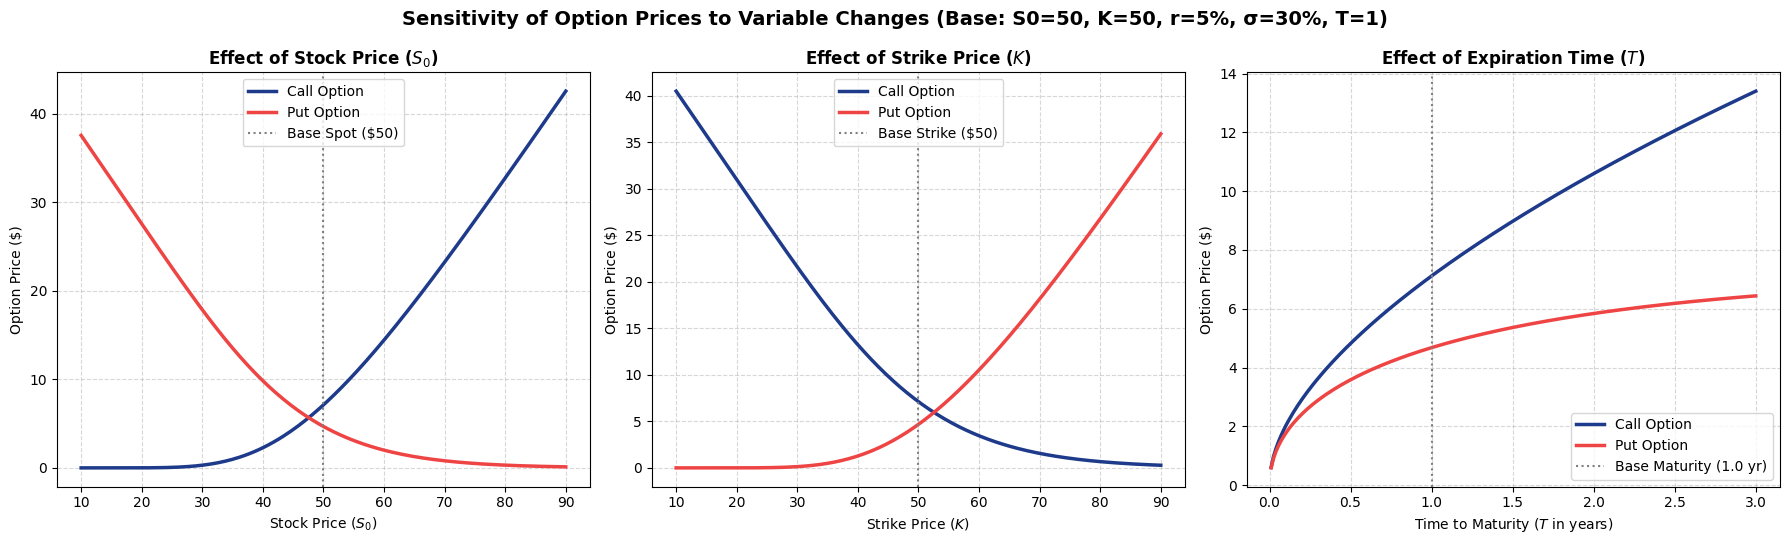

In [29]:
# --- Black-Scholes-Merton European Pricing Formula ---
def black_scholes(option_type, s, k, r, sigma, t):
    if t <= 0:
        if option_type.lower() == 'call':
            return max(s - k, 0.0)
        else:
            return max(k - s, 0.0)
    d1 = (np.log(s / k) + (r + 0.5 * sigma**2) * t) / (sigma * np.sqrt(t))
    d2 = d1 - sigma * np.sqrt(t)
    if option_type.lower() == 'call':
        return s * norm.cdf(d1) - k * np.exp(-r * t) * norm.cdf(d2)
    else:
        return k * np.exp(-r * t) * norm.cdf(-d2) - s * norm.cdf(-d1)

# Base parameters
s_base = 50.0
k_base = 50.0
r_base = 0.05
s_vol = 0.30
t_base = 1.0

# 1. Varying Stock Price S0
s_range = np.linspace(10, 90, 200)
calls_vs_s = [black_scholes('call', s, k_base, r_base, s_vol, t_base) for s in s_range]
puts_vs_s = [black_scholes('put', s, k_base, r_base, s_vol, t_base) for s in s_range]

# 2. Varying Strike Price K
k_range = np.linspace(10, 90, 200)
calls_vs_k = [black_scholes('call', s_base, k, r_base, s_vol, t_base) for k in k_range]
puts_vs_k = [black_scholes('put', s_base, k, r_base, s_vol, t_base) for k in k_range]

# 3. Varying Time to Expiration T
t_range = np.linspace(0.01, 3.0, 200)
calls_vs_t = [black_scholes('call', s_base, k_base, r_base, s_vol, t) for t in t_range]
puts_vs_t = [black_scholes('put', s_base, k_base, r_base, s_vol, t) for t in t_range]

# Plotting the three effects in a beautiful multi-panel subplot
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.5), dpi=100)

# Plot 1: Varying S0
ax1.plot(s_range, calls_vs_s, color=navy_blue, linewidth=2.5, label='Call Option')
ax1.plot(s_range, puts_vs_s, color=crimson, linewidth=2.5, label='Put Option')
ax1.axvline(s_base, color='gray', linestyle=':', label='Base Spot ($50)')
ax1.set_title('Effect of Stock Price ($S_0$)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Stock Price ($S_0$)', fontsize=10)
ax1.set_ylabel('Option Price ($)', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(frameon=True)

# Plot 2: Varying K
ax2.plot(k_range, calls_vs_k, color=navy_blue, linewidth=2.5, label='Call Option')
ax2.plot(k_range, puts_vs_k, color=crimson, linewidth=2.5, label='Put Option')
ax2.axvline(k_base, color='gray', linestyle=':', label='Base Strike ($50)')
ax2.set_title('Effect of Strike Price ($K$)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Strike Price ($K$)', fontsize=10)
ax2.set_ylabel('Option Price ($)', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(frameon=True)

# Plot 3: Varying T
ax3.plot(t_range, calls_vs_t, color=navy_blue, linewidth=2.5, label='Call Option')
ax3.plot(t_range, puts_vs_t, color=crimson, linewidth=2.5, label='Put Option')
ax3.axvline(t_base, color='gray', linestyle=':', label='Base Maturity (1.0 yr)')
ax3.set_title('Effect of Expiration Time ($T$)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Time to Maturity ($T$ in years)', fontsize=10)
ax3.set_ylabel('Option Price ($)', fontsize=10)
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(frameon=True)

plt.suptitle('Sensitivity of Option Prices to Variable Changes (Base: S0=50, K=50, r=5%, σ=30%, T=1)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


---
## 2. Theory of Early Exercise of Options

American options grant the holder the right to exercise the contract *at any point* prior to the expiration date. However, having the right to exercise early does not mean doing so is economically optimal. 

Let's break down the rules of early exercise for calls and puts, both **with** and **without** dividends, citing John Hull's definitive analysis.

---

### A. Call Options on Non-Dividend-Paying Stocks (Section 11.5)
* **Rule**: It is **never** optimal to exercise an American call option early if the underlying stock pays no dividends ($C = c$).
* **Intuition**: 
  1. **Time Value of Money**: Exercising the call requires paying the strike price $K$. From a cash perspective, paying $K$ later is always better than paying $K$ today because your money continues to earn interest in a risk-free account:
     $$C \ge S_0 - K e^{-rT} > S_0 - K \quad (\text{for } r > 0, T > 0)$$
  2. **Insurance Value**: Keeping the option intact protects you from downside risk. If you exercise early and take ownership of the stock, you lose this insurance; if the stock subsequently crashes, you bear the full loss.
* **Hull Citation**: Section 11.5 states:
  > *"There are two reasons an American call on a non-dividend-paying stock should not be exercised early. One relates to the insurance that it provides... once the option has been exercised and the strike price has been exchanged for the stock price, this insurance vanishes. The other reason concerns the time value of money."*

---

### B. Call Options on Dividend-Paying Stocks (Section 11.7)
* **Rule**: It **can** be optimal to exercise an American call option early immediately before the stock goes ex-dividend. It is never optimal to exercise at any other time.
* **Intuition**: On the ex-dividend date, the stock price drops by approximately the dividend amount $D$. 
  * If the dividend $D$ is sufficiently large, the option holder is willing to forfeit the call's remaining time/insurance value and pay the strike $K$ early to acquire the stock and capture the dividend.
  * The exact condition that makes early exercise attractive right before the ex-dividend date is:
    $$D > K \left( 1 - e^{-r(T - t_d)} \right)$$
    where $t_d$ is the dividend date, and $T - t_d$ is the remaining life of the option.

---

### C. Put Options on Non-Dividend-Paying Stocks (Section 11.6)
* **Rule**: It **can** be optimal to exercise an American put option on a non-dividend-paying stock early, particularly when the option is deep-in-the-money.
* **Intuition**: 
  * Exercising a put option means you **receive** the strike price cash $K$ immediately. 
  * When the stock price is extremely low (near zero), the put option's insurance value becomes worthless (since the stock cannot drop below zero). 
  * Pocketing $K$ immediately and earning interest on it is far superior to waiting until expiration. Early exercise is triggered when the spot price falls below a critical barrier $S^*$.
* **Hull Citation**: Section 11.6 states:
  > *"It can be optimal to exercise an American put option on a non-dividend-paying stock early... receiving $K$ now is preferable to receiving $K$ in the future."*

---

### D. Put Options on Dividend-Paying Stocks (Section 11.7)
* **Rule**: Dividends **reduce** the incentive to exercise an American put option early.
* **Intuition**: Since dividends cause the stock price to drop, and a drop in stock price benefits a put option holder, the put holder prefers to **wait** until after the ex-dividend date to let the stock price decline before deciding to exercise.


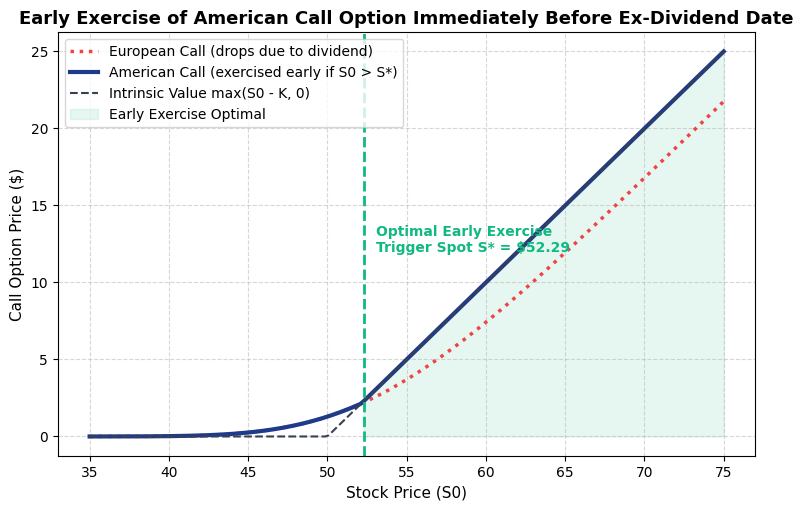

In [30]:
# --- Plotting Call Option Early Exercise Boundary immediately before Ex-Dividend ---
# We show that when S0 is very high, the American call price merges with the intrinsic value line
# immediately before ex-dividend, triggering early exercise, while the European call dips below it.

s_range = np.linspace(35, 75, 200)
k = 50.0
r = 0.05
sigma = 0.25
t_remaining = 0.3
div = 4.0 # Large dividend

# Adjusted Spot for European Call pricing (S0 - PV of Dividend)
calls_euro = []
calls_amer = []

for s in s_range:
    # European call takes the hit of the dividend ex-date drop
    s_adj = max(s - div * np.exp(-r * 0.01), 0.001)
    c_e = black_scholes('call', s_adj, k, r, sigma, t_remaining)
    calls_euro.append(c_e)
    # American call immediately before ex-div can be exercised early to capture intrinsic value,
    # or kept if out-of-the-money
    c_a = max(c_e, s - k)
    calls_amer.append(c_a)

intrinsic = np.maximum(s_range - k, 0)

plt.figure(figsize=(9, 5.5), dpi=100)
plt.plot(s_range, calls_euro, color=crimson, linewidth=2.5, linestyle=':', label='European Call (drops due to dividend)')
plt.plot(s_range, calls_amer, color=navy_blue, linewidth=3, label='American Call (exercised early if S0 > S*)')
plt.plot(s_range, intrinsic, color=dark_gray, linestyle='--', linewidth=1.5, label='Intrinsic Value max(S0 - K, 0)')

# Highlight early exercise region where American Call is equal to intrinsic value
exercise_boundary_idx = np.where(np.array(calls_amer) == intrinsic)[0]
if len(exercise_boundary_idx) > 0:
    s_star = s_range[exercise_boundary_idx[0]]
    plt.axvline(s_star, color=emerald, linestyle='--', linewidth=2)
    plt.text(s_star + 0.8, 12, f'Optimal Early Exercise\nTrigger Spot S* = ${s_star:.2f}', fontsize=10, fontweight='bold', color=emerald)
    plt.fill_between(s_range[exercise_boundary_idx], np.array(calls_amer)[exercise_boundary_idx], 0, color=emerald, alpha=0.1, label='Early Exercise Optimal')

plt.title('Early Exercise of American Call Option Immediately Before Ex-Dividend Date', fontsize=13, fontweight='bold')
plt.xlabel('Stock Price (S0)', fontsize=11)
plt.ylabel('Call Option Price ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, fontsize=10)
plt.show()


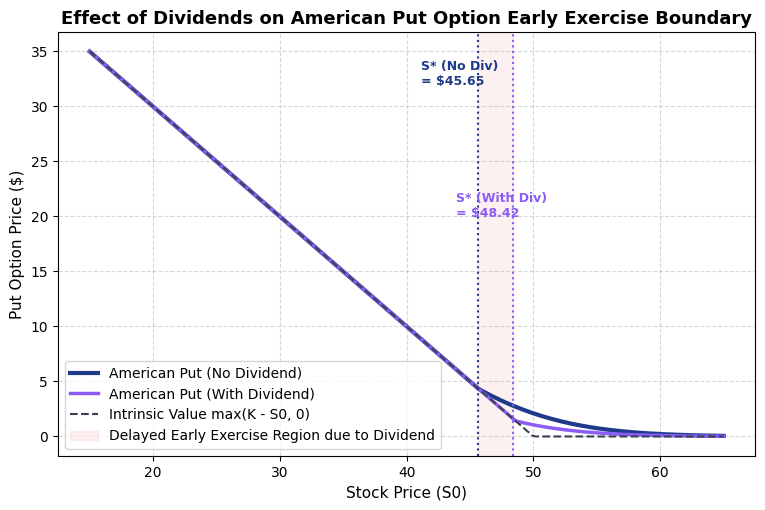

In [31]:
# --- Plotting Put Option Early Exercise Boundary Shift: Non-Dividend vs. Dividend Stock ---
# We show that dividends make put early exercise less attractive, shifting the critical S* barrier to the left (lower).

s_range = np.linspace(15, 65, 200)
k = 50.0
r = 0.06
sigma = 0.20
t = 0.5
div = 3.5

puts_no_div = []
puts_with_div = []
intrinsic = np.maximum(k - s_range, 0)

for s in s_range:
    # 1. Non-dividend put
    p_no = black_scholes('put', s, k, r, sigma, t)
    puts_no_div.append(max(p_no, k - s))
    
    # 2. Dividend put (spot adjusted up by PV of dividend for pricing before ex-date)
    s_adj = s + div * np.exp(-r * 0.2)
    p_div = black_scholes('put', s_adj, k, r, sigma, t)
    puts_with_div.append(max(p_div, k - s))

plt.figure(figsize=(9, 5.5), dpi=100)
plt.plot(s_range, puts_no_div, color=navy_blue, linewidth=3, label='American Put (No Dividend)')
plt.plot(s_range, puts_with_div, color=violet, linewidth=2.5, label='American Put (With Dividend)')
plt.plot(s_range, intrinsic, color=dark_gray, linestyle='--', label='Intrinsic Value max(K - S0, 0)')

# Find early exercise spots
star_no_idx = np.where(np.array(puts_no_div) == intrinsic)[0]
star_div_idx = np.where(np.array(puts_with_div) == intrinsic)[0]

if len(star_no_idx) > 0:
    s_star_no = s_range[star_no_idx[-1]]
    plt.axvline(s_star_no, color=navy_blue, linestyle=':')
    plt.text(s_star_no - 4.5, 32, f'S* (No Div)\n= ${s_star_no:.2f}', fontsize=9, fontweight='bold', color=navy_blue)

if len(star_div_idx) > 0:
    s_star_div = s_range[star_div_idx[-1]]
    plt.axvline(s_star_div, color=violet, linestyle=':')
    plt.text(s_star_div - 4.5, 20, f'S* (With Div)\n= ${s_star_div:.2f}', fontsize=9, fontweight='bold', color=violet)

# Shading to show that Dividends delay early exercise (shift S* to the left)
if len(star_no_idx) > 0 and len(star_div_idx) > 0:
    plt.axvspan(s_star_div, s_star_no, color=crimson, alpha=0.08, label='Delayed Early Exercise Region due to Dividend')

plt.title('Effect of Dividends on American Put Option Early Exercise Boundary', fontsize=13, fontweight='bold')
plt.xlabel('Stock Price (S0)', fontsize=11)
plt.ylabel('Put Option Price ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, fontsize=10)
plt.show()


---
## 1. Mathematical Bounds for Stock Options

Without making assumptions about stock price distribution or volatility, standard no-arbitrage arguments dictate robust upper and lower boundaries for option values.

### Call Options on Non-Dividend-Paying Stocks
* **Upper Bound**: An option to buy a share can never be worth more than the share itself:
  $$c \le S_0 \quad \text{and} \quad C \le S_0$$
* **Lower Bound**: The price of a European call option ($c$) must satisfy:
  $$c \ge \max(S_0 - K e^{-rT}, 0)$$
* **American Call**: Since early exercise is not optimal when there are no dividends ($C = c$), the bounds remain identical:
  $$C \ge \max(S_0 - K e^{-rT}, 0)$$

---

### Put Options on Non-Dividend-Paying Stocks
* **Upper Bound**: An option to sell a share can never be worth more than the strike price:
  $$p \le K e^{-rT} \quad \text{and} \quad P \le K$$
* **Lower Bound**: The price of a European put option ($p$) must satisfy:
  $$p \ge \max(K e^{-rT} - S_0, 0)$$
* **American Put ($P$)**: Because it can be exercised immediately at any time, its lower bound is stronger (intrinsic value):
  $$P \ge \max(K - S_0, 0)$$


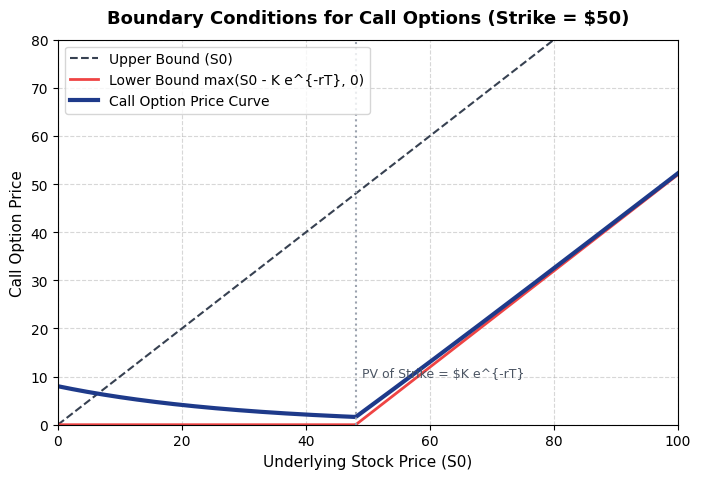

In [32]:
# --- Plotting bounds for European and American Call Options ---
s_range = np.linspace(0, 100, 300)
strike = 50.0
r = 0.08
t = 0.5
pv_strike = strike * np.exp(-r * t)

upper_bound_call = s_range
lower_bound_call = np.maximum(s_range - pv_strike, 0)
theoretical_call = lower_bound_call + 8.0 * np.exp(-s_range/30.0) # Smooth realistic curve

plt.figure(figsize=(8, 5), dpi=100)
plt.plot(s_range, upper_bound_call, color=dark_gray, linestyle='--', label='Upper Bound (S0)')
plt.plot(s_range, lower_bound_call, color=crimson, linewidth=2, label='Lower Bound max(S0 - K e^{-rT}, 0)')
plt.plot(s_range, theoretical_call, color=navy_blue, linewidth=3, label='Call Option Price Curve')

plt.axvline(pv_strike, color='#9CA3AF', linestyle=':')
plt.text(pv_strike + 1, 10, 'PV of Strike = $K e^{-rT}', fontsize=9, color='#4B5563')

plt.title('Boundary Conditions for Call Options (Strike = $50)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Underlying Stock Price (S0)', fontsize=11)
plt.ylabel('Call Option Price', fontsize=11)
plt.xlim(0, 100)
plt.ylim(0, 80)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, fontsize=10)
plt.show()


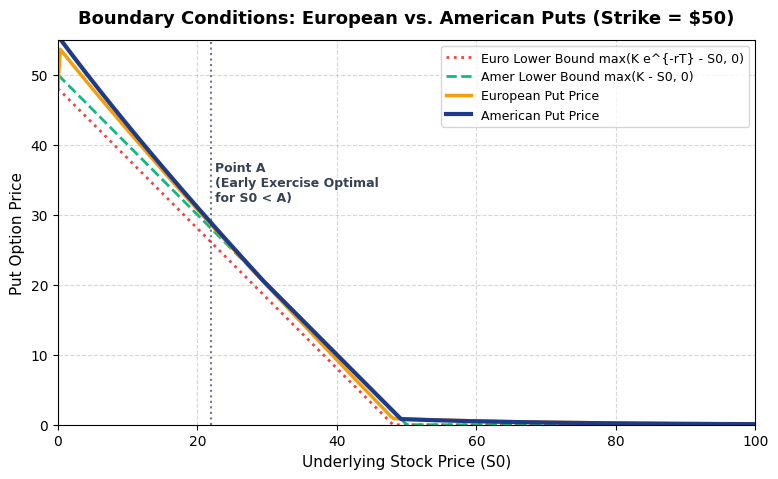

In [33]:
# --- Plotting bounds for European and American Put Options ---
s_range = np.linspace(0, 100, 300)
strike = 50.0
r = 0.08
t = 0.5
pv_strike = strike * np.exp(-r * t)

# Bounds
upper_bound_euro_put = pv_strike
lower_bound_euro_put = np.maximum(pv_strike - s_range, 0)
lower_bound_amer_put = np.maximum(strike - s_range, 0)

# Theoretical curves
euro_put_price = lower_bound_euro_put + 6.0 * np.exp(-s_range/25.0) * (s_range > 0)
amer_put_price = np.maximum(lower_bound_amer_put, lower_bound_euro_put + 7.5 * np.exp(-s_range/22.0))

plt.figure(figsize=(9, 5), dpi=100)
plt.plot(s_range, lower_bound_euro_put, color=crimson, linestyle=':', linewidth=2, label='Euro Lower Bound max(K e^{-rT} - S0, 0)')
plt.plot(s_range, lower_bound_amer_put, color=emerald, linestyle='--', linewidth=2, label='Amer Lower Bound max(K - S0, 0)')
plt.plot(s_range, euro_put_price, color=amber, linewidth=2.5, label='European Put Price')
plt.plot(s_range, amer_put_price, color=navy_blue, linewidth=3, label='American Put Price')

# Mark the early exercise critical point A
plt.axvline(22.0, color=dark_gray, linestyle=':', alpha=0.7)
plt.text(22.5, 32, 'Point A\n(Early Exercise Optimal\nfor S0 < A)', fontsize=9, fontweight='bold', color=dark_gray)

plt.title('Boundary Conditions: European vs. American Puts (Strike = $50)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Underlying Stock Price (S0)', fontsize=11)
plt.ylabel('Put Option Price', fontsize=11)
plt.xlim(0, 100)
plt.ylim(0, 55)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, fontsize=9)
plt.show()


---
# Part 2: Chapter 11 Practice Questions & Python Solutions

Let's master the properties of stock options by implementing rigorous quantitative solutions for **Practice Questions 11.1 to 11.26**.


---
## Practice Question 11.1

### Question
An investor buys a 4-month call option on a non-dividend-paying stock when the stock price is $28, the strike price is $25, and the risk-free interest rate is 8% per annum. What is a lower bound for the price?

### Solution
The lower bound for a European or American call option on a non-dividend-paying stock is given by:
$$\text{Lower Bound} = \max(S_0 - K e^{-rT}, 0)$$

Given parameters:
* Stock price $S_0 = 28$
* Strike price $K = 25$
* Time to maturity $T = 4/12 = 0.3333$
* Risk-free rate $r = 0.08$


PV of Strike Price (K e^{-rT}): $24.3421
Lower Bound for the 4-month Call Option: $3.66



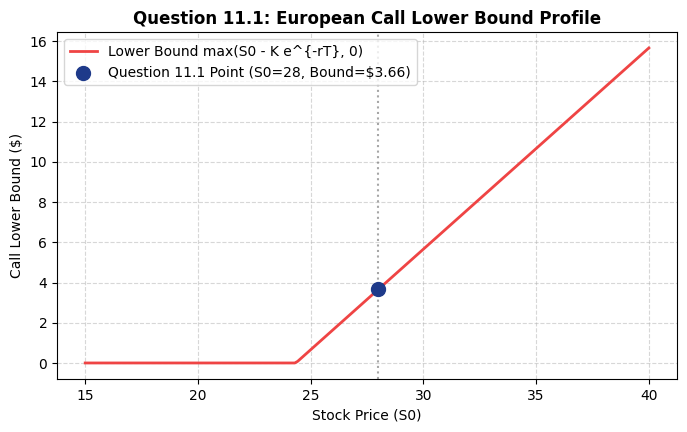

In [34]:
# --- Question 11.1 Solution & Plot ---
s0 = 28.0
k = 25.0
t = 4.0 / 12.0
r = 0.08

pv_k = k * np.exp(-r * t)
lower_bound_call = max(s0 - pv_k, 0.0)

print(f"PV of Strike Price (K e^{{-rT}}): ${pv_k:.4f}")
print(f"Lower Bound for the 4-month Call Option: ${lower_bound_call:.2f}\n")

# --- Visualize options bounds with Question 11.1 spot point ---
s_grid = np.linspace(15, 40, 200)
pv_k_grid = k * np.exp(-r * t)
bounds_grid = np.maximum(s_grid - pv_k_grid, 0)

plt.figure(figsize=(8, 4.5), dpi=100)
plt.plot(s_grid, bounds_grid, color=crimson, linewidth=2, label='Lower Bound max(S0 - K e^{-rT}, 0)')
plt.scatter([s0], [lower_bound_call], color=navy_blue, s=100, zorder=5, label=f'Question 11.1 Point (S0=28, Bound=${lower_bound_call:.2f})')
plt.axvline(s0, color='gray', linestyle=':', alpha=0.7)

plt.title('Question 11.1: European Call Lower Bound Profile', fontsize=12, fontweight='bold')
plt.xlabel('Stock Price (S0)', fontsize=10)
plt.ylabel('Call Lower Bound ($)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True)
plt.show()


---
## Practice Question 11.2

### Question
What is a lower bound for the price of a 1-month European put option on a non-dividend-paying stock when the stock price is $12, the strike price is $15, and the risk-free interest rate is 6% per annum?

### Solution
The lower bound for a European put option is given by:
$$\text{Lower Bound} = \max(K e^{-rT} - S_0, 0)$$

Given parameters:
* Stock price $S_0 = 12$
* Strike price $K = 15$
* Time to maturity $T = 1/12 = 0.0833$
* Risk-free rate $r = 0.06$


PV of Strike Price (K e^{-rT}): $14.9252
Lower Bound for the 1-month European Put Option: $2.93



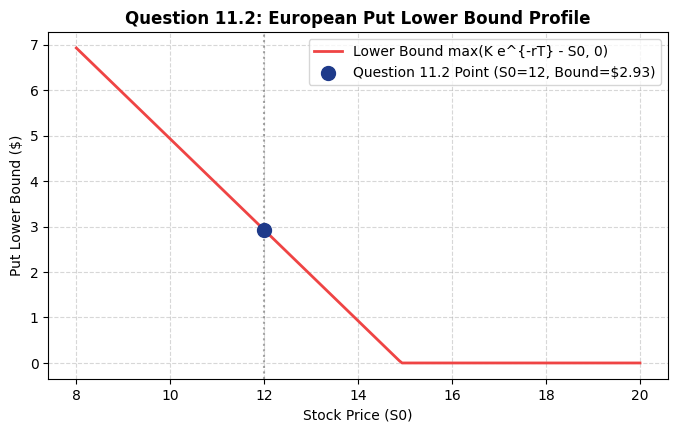

In [35]:
# --- Question 11.2 Solution & Plot ---
s0 = 12.0
k = 15.0
t = 1.0 / 12.0
r = 0.06

pv_k = k * np.exp(-r * t)
lower_bound_put = max(pv_k - s0, 0.0)

print(f"PV of Strike Price (K e^{{-rT}}): ${pv_k:.4f}")
print(f"Lower Bound for the 1-month European Put Option: ${lower_bound_put:.2f}\n")

# --- Visualize put bounds with Question 11.2 spot point ---
s_grid = np.linspace(8, 20, 200)
pv_k_grid = k * np.exp(-r * t)
bounds_grid = np.maximum(pv_k_grid - s_grid, 0)

plt.figure(figsize=(8, 4.5), dpi=100)
plt.plot(s_grid, bounds_grid, color=crimson, linewidth=2, label='Lower Bound max(K e^{-rT} - S0, 0)')
plt.scatter([s0], [lower_bound_put], color=navy_blue, s=100, zorder=5, label=f'Question 11.2 Point (S0=12, Bound=${lower_bound_put:.2f})')
plt.axvline(s0, color='gray', linestyle=':', alpha=0.7)

plt.title('Question 11.2: European Put Lower Bound Profile', fontsize=12, fontweight='bold')
plt.xlabel('Stock Price (S0)', fontsize=10)
plt.ylabel('Put Lower Bound ($)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True)
plt.show()


---
## Practice Question 11.3

### Question
Give two reasons why the early exercise of an American call option on a non-dividend-paying stock is not optimal. The first reason should involve the time value of money. The second should apply even if interest rates are zero.

### Solution
1. **Time Value of Money (Interest on Strike)**:
   * Exercising a call requires the holder to pay the strike price $K$ to receive the stock. Delaying exercise keeps the cash $K$ earning interest in the risk-free account for as long as possible. The payment is deferred, which is always optimal when $r > 0$.
2. **Insurance Value against Downside Risk**:
   * Holding a call option provides downside protection (insurance). If the stock price falls below $K$, the call holder's maximum loss is capped at the premium already paid, and they simply let the option expire.
   * If the option is exercised early, the holder exchanges the option for the stock itself. This immediately vanishes the insurance; if the stock subsequently crashes, the investor suffers the full capital loss of the stock. This holds true even if interest rates are exactly zero.


---
## Practice Question 11.4

### Question
“The early exercise of an American put is a trade-off between the time value of money and the insurance value of a put.” Explain this statement.

### Solution
1. **Time Value of Money (Receiving Cash Early)**:
   * Unlike a call where you pay cash, exercising a put option allows you to **receive** the strike price cash $K$ immediately. Under positive interest rates, receiving cash now is worth more than receiving it at maturity. This creates a strong incentive for early exercise.
2. **Insurance Value of the Put**:
   * A put option acts as insurance against the stock price falling. By exercising early and selling the stock for $K$, the investor relinquishes this insurance. If the stock drops further, they miss out on additional potential gains.
3. **The Trade-off**:
   * If the stock price is already extremely low (near zero), the insurance value is virtually worthless because the stock cannot fall below zero. In this case, the time value of money dominates, and immediate early exercise is optimal. If the option is only marginally in-the-money, the insurance value dominates, and it is better to wait.


---
## Practice Question 11.5

### Question
Why is an American call option on a dividend-paying stock always worth at least as much as its intrinsic value. Is the same true of a European call option? Explain your answer.

### Solution
* **American Call Option**:
  * An American option can be exercised at any time. If its market price fell below its intrinsic value ($S_0 - K$), an arbitrageur would immediately buy the option, exercise it immediately, and make a risk-free profit. Thus, $C \ge \max(S_0 - K, 0)$ must hold at all times.
* **European Call Option**:
  * A European call option cannot be exercised early. If a dividend $D$ is paid during the option's life, the stock price drops by approximately $D$ on the ex-dividend date.
  * Near the ex-dividend date, the stock price $S_0$ might be high, but because the option cannot be exercised before maturity, the expected post-dividend price drop reduces the option value.
  * In this scenario, the European call option price can easily fall **below** its pre-dividend intrinsic value ($S_0 - K$).

Below we demonstrate this visually: we model a European Call option on a stock that will pay a massive **$\$8.00$ cash dividend** near maturity. As you can see, when the stock price $S_0$ is high, the European Call price curve actually **dips below its intrinsic value** line ($S_0 - K$).


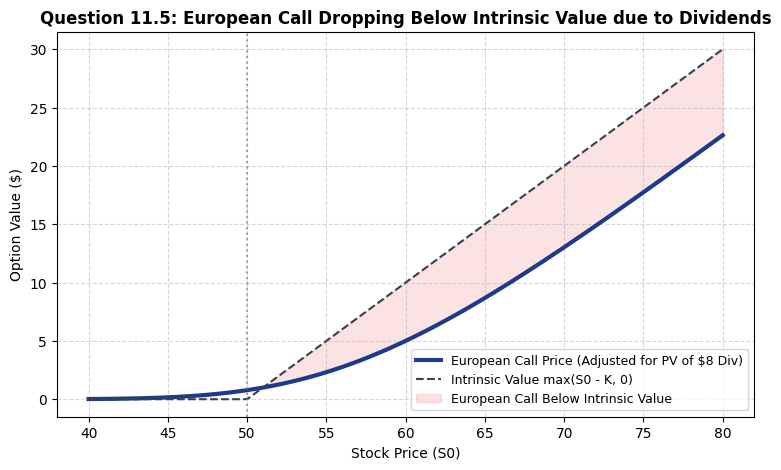

In [36]:
# --- Plotting European Call Dipping Below Intrinsic Value due to Dividends ---
s_grid = np.linspace(40, 80, 200)
k = 50.0
r = 0.02
sigma = 0.25
t = 0.5
div = 8.0
t_div = 0.4 # dividend paid near the end

# BSM call adjusting spot for dividend PV
pv_div = div * np.exp(-r * t_div)
calls_with_div = []
for s in s_grid:
    s_adj = max(s - pv_div, 0.001)
    calls_with_div.append(black_scholes('call', s_adj, k, r, sigma, t))

intrinsic = np.maximum(s_grid - k, 0)

plt.figure(figsize=(9, 5), dpi=100)
plt.plot(s_grid, calls_with_div, color=navy_blue, linewidth=3, label='European Call Price (Adjusted for PV of $8 Div)')
plt.plot(s_grid, intrinsic, color=dark_gray, linestyle='--', linewidth=1.5, label='Intrinsic Value max(S0 - K, 0)')

# Shading the region where European Call Price < Intrinsic Value
below_intrinsic = np.array(calls_with_div) < intrinsic
plt.fill_between(s_grid, calls_with_div, intrinsic, where=below_intrinsic, color=crimson, alpha=0.15, label='European Call Below Intrinsic Value')

plt.axvline(k, color='gray', linestyle=':', alpha=0.7)
plt.title('Question 11.5: European Call Dropping Below Intrinsic Value due to Dividends', fontsize=12, fontweight='bold')
plt.xlabel('Stock Price (S0)', fontsize=10)
plt.ylabel('Option Value ($)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, fontsize=9)
plt.show()


---
## Practice Question 11.6

### Question
The price of a non-dividend-paying stock is $19 and the price of a 3-month European call option on the stock with a strike price of $20 is $1. The risk-free rate is 4% per annum. What is the price of a 3-month European put option with a strike price of $20?

### Solution
We use the **Put-Call Parity** formula for non-dividend-paying stocks:
$$c + K e^{-rT} = p + S_0$$

We can isolate the put price ($p$):
$$p = c + K e^{-rT} - S_0$$

Given parameters:
* $S_0 = 19$
* $K = 20$
* $T = 3/12 = 0.25$
* $r = 0.04$
* $c = 1$


PV of Strike Price (K e^{-rT}): $19.8010
Price of the European Put Option: $1.80



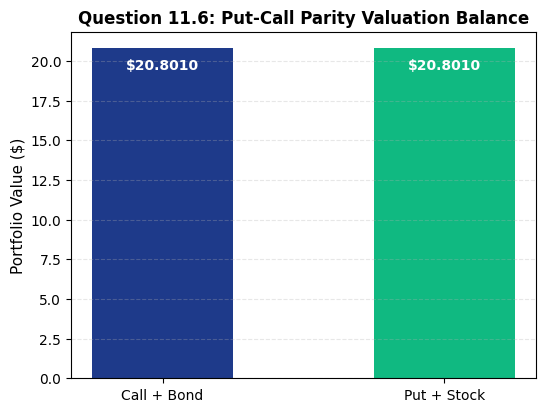

In [37]:
# --- Question 11.6 Solution & Put-Call Parity Plot ---
s0 = 19.0
k = 20.0
t = 0.25
r = 0.04
c = 1.0

pv_k = k * np.exp(-r * t)
p = c + pv_k - s0

print(f"PV of Strike Price (K e^{{-rT}}): ${pv_k:.4f}")
print(f"Price of the European Put Option: ${p:.2f}\n")

# --- Plotting the Put-Call Parity Balance ---
labels = ['Call + Bond', 'Put + Stock']
values = [c + pv_k, p + s0]

plt.figure(figsize=(6, 4.5), dpi=100)
bars = plt.bar(labels, values, color=[navy_blue, emerald], width=0.5)
plt.ylabel('Portfolio Value ($)', fontsize=11)
plt.title('Question 11.6: Put-Call Parity Valuation Balance', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height - 1.5, f"${height:.4f}", ha='center', va='bottom', color='white', fontweight='bold')

plt.show()


---
## Practice Question 11.7

### Question
Explain why the arguments leading to put–call parity for European options cannot be used to give a similar result for American options.

### Solution
* Put-Call Parity is derived by constructing two portfolios:
  * **Portfolio A**: One European call option plus cash equal to $K e^{-rT}$.
  * **Portfolio B**: One European put option plus one share.
* Because both options can only be exercised at maturity $T$, both portfolios are guaranteed to be worth exactly $\max(S_T, K)$ at maturity, forcing their initial values to be equal.
* For American options, **early exercise is possible**. 
  * If the put is exercised early, Portfolio B is terminated before maturity.
  * Because the optimal early exercise times for the American call and American put are different and depend on stock price paths, we cannot guarantee that the two portfolios will have the same value at any single point in time. 
  * As a result, Put-Call Parity holds only as an **inequality range** for American options:
    $$S_0 - K \le C - P \le S_0 - K e^{-rT}$$


---
## Practice Question 11.8

### Question
What is a lower bound for the price of a 6-month call option on a non-dividend-paying stock when the stock price is $80, the strike price is $75, and the risk-free interest rate is 10% per annum?

### Solution
$$\text{Lower Bound} = \max(S_0 - K e^{-rT}, 0)$$

Given parameters:
* $S_0 = 80$
* $K = 75$
* $T = 0.5$
* $r = 0.10$


PV of Strike Price (K e^{-rT}): $71.3422


Lower Bound for the 6-month Call Option: $8.66



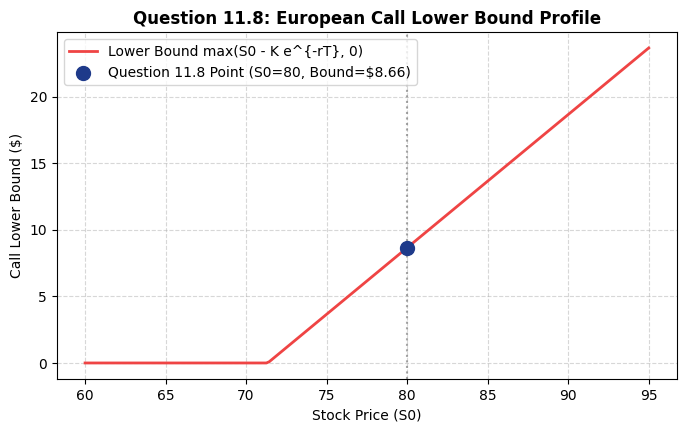

In [38]:
# --- Question 11.8 Solution & Plot ---
s0 = 80.0
k = 75.0
t = 0.5
r = 0.10

pv_k = k * np.exp(-r * t)
lower_bound_call = max(s0 - pv_k, 0.0)

print(f"PV of Strike Price (K e^{{-rT}}): ${pv_k:.4f}")
print(f"Lower Bound for the 6-month Call Option: ${lower_bound_call:.2f}\n")

# --- Visualize options bounds with Question 11.8 spot point ---
s_grid = np.linspace(60, 95, 200)
pv_k_grid = k * np.exp(-r * t)
bounds_grid = np.maximum(s_grid - pv_k_grid, 0)

plt.figure(figsize=(8, 4.5), dpi=100)
plt.plot(s_grid, bounds_grid, color=crimson, linewidth=2, label='Lower Bound max(S0 - K e^{-rT}, 0)')
plt.scatter([s0], [lower_bound_call], color=navy_blue, s=100, zorder=5, label=f'Question 11.8 Point (S0=80, Bound=${lower_bound_call:.2f})')
plt.axvline(s0, color='gray', linestyle=':', alpha=0.7)

plt.title('Question 11.8: European Call Lower Bound Profile', fontsize=12, fontweight='bold')
plt.xlabel('Stock Price (S0)', fontsize=10)
plt.ylabel('Call Lower Bound ($)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True)
plt.show()


---
## Practice Question 11.9

### Question
What is a lower bound for the price of a 2-month European put option on a non-dividend-paying stock when the stock price is $58, the strike price is $65, and the risk-free interest rate is 5% per annum?

### Solution
$$\text{Lower Bound} = \max(K e^{-rT} - S_0, 0)$$

Given parameters:
* $S_0 = 58$
* $K = 65$
* $T = 2/12 = 0.1667$
* $r = 0.05$


PV of Strike Price (K e^{-rT}): $64.4606
Lower Bound for the 2-month European Put Option: $6.46



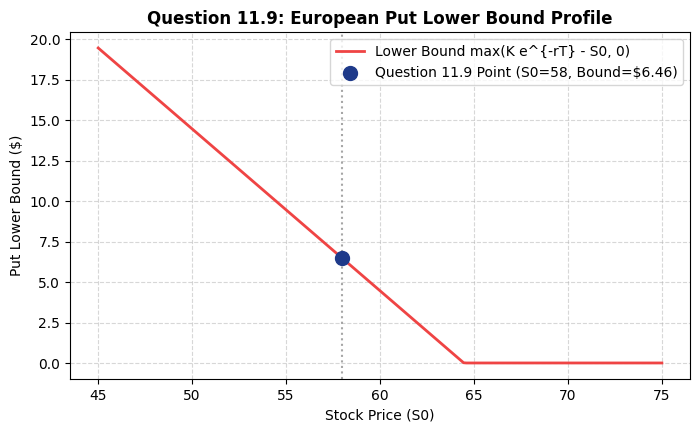

In [39]:
# --- Question 11.9 Solution & Plot ---
s0 = 58.0
k = 65.0
t = 2.0 / 12.0
r = 0.05

pv_k = k * np.exp(-r * t)
lower_bound_put = max(pv_k - s0, 0.0)

print(f"PV of Strike Price (K e^{{-rT}}): ${pv_k:.4f}")
print(f"Lower Bound for the 2-month European Put Option: ${lower_bound_put:.2f}\n")

# --- Visualize put bounds with Question 11.9 spot point ---
s_grid = np.linspace(45, 75, 200)
pv_k_grid = k * np.exp(-r * t)
bounds_grid = np.maximum(pv_k_grid - s_grid, 0)

plt.figure(figsize=(8, 4.5), dpi=100)
plt.plot(s_grid, bounds_grid, color=crimson, linewidth=2, label='Lower Bound max(K e^{-rT} - S0, 0)')
plt.scatter([s0], [lower_bound_put], color=navy_blue, s=100, zorder=5, label=f'Question 11.9 Point (S0=58, Bound=${lower_bound_put:.2f})')
plt.axvline(s0, color='gray', linestyle=':', alpha=0.7)

plt.title('Question 11.9: European Put Lower Bound Profile', fontsize=12, fontweight='bold')
plt.xlabel('Stock Price (S0)', fontsize=10)
plt.ylabel('Put Lower Bound ($)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True)
plt.show()


---
## Practice Question 11.10

### Question
A 4-month European call option on a dividend-paying stock is currently selling for $5. The stock price is $64, the strike price is $60, and a dividend of $0.80 is expected in 1 month. The risk-free interest rate is 12% per annum for all maturities. What opportunities are there for an arbitrageur?

### Solution
For a European call option on a dividend-paying stock, the lower bound is:
$$\text{Lower Bound} = S_0 - D - K e^{-rT}$$

Where:
* $S_0 = 64$
* $K = 60$
* $T = 4/12 = 0.3333$
* $r = 0.12$
* Dividend $D = 0.80$ paid at $t_d = 1/12$
* Present value of dividend $D_{pv} = 0.80 \times e^{-0.12 \times 1/12}$


PV of Dividend: $0.7920
PV of Strike Price: $57.6474
Theoretical Lower Bound: $5.56

Arbitrage Opportunity exists! Market price $5.00 is below the lower bound of $5.56.


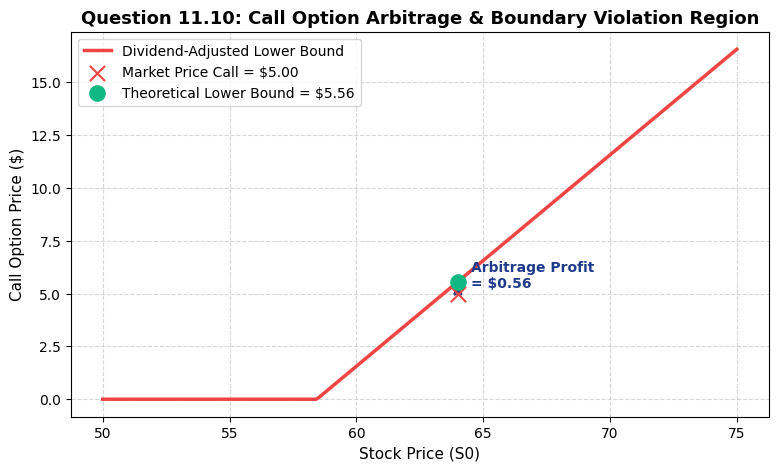

In [40]:
# --- Question 11.10 Solution & Arbitrage Profit Plot ---
s0 = 64.0
k = 60.0
t = 4.0 / 12.0
r = 0.12
div = 0.80
t_div = 1.0 / 12.0
c_market = 5.0

pv_div = div * np.exp(-r * t_div)
pv_k = k * np.exp(-r * t)
lower_bound = s0 - pv_div - pv_k

print(f"PV of Dividend: ${pv_div:.4f}")
print(f"PV of Strike Price: ${pv_k:.4f}")
print(f"Theoretical Lower Bound: ${lower_bound:.2f}\n")

if c_market < lower_bound:
    profit = lower_bound - c_market
    print(f"Arbitrage Opportunity exists! Market price ${c_market:.2f} is below the lower bound of ${lower_bound:.2f}.")
    
    # Let's plot the boundary violation region to show the arbitrage profit space
    s_grid = np.linspace(50, 75, 200)
    pv_div_grid = div * np.exp(-r * t_div)
    pv_k_grid = k * np.exp(-r * t)
    bounds_grid = np.maximum(s_grid - pv_div_grid - pv_k_grid, 0)
    
    plt.figure(figsize=(9, 5), dpi=100)
    plt.plot(s_grid, bounds_grid, color=crimson, linewidth=2.5, label='Dividend-Adjusted Lower Bound')
    plt.scatter([s0], [c_market], color=crimson, s=120, zorder=5, marker='x', label=f'Market Price Call = $5.00')
    plt.scatter([s0], [lower_bound], color=emerald, s=120, zorder=5, marker='o', label=f'Theoretical Lower Bound = ${lower_bound:.2f}')
    
    # Draw arrow showing the arbitrage gap
    plt.annotate('', xy=(s0, lower_bound), xytext=(s0, c_market),
                 arrowprops=dict(arrowstyle="<->", color=navy_blue, lw=2.5))
    plt.text(s0 + 0.5, (c_market + lower_bound)/2.0, f'Arbitrage Profit\n= ${profit:.2f}', fontsize=10, fontweight='bold', color=navy_blue)
    
    plt.title('Question 11.10: Call Option Arbitrage & Boundary Violation Region', fontsize=13, fontweight='bold')
    plt.xlabel('Stock Price (S0)', fontsize=11)
    plt.ylabel('Call Option Price ($)', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(frameon=True, fontsize=10)
    plt.show()


---
## Practice Question 11.11

### Question
A 1-month European put option on a non-dividend-paying stock is currently selling for $2.50. The stock price is $47, the strike price is $50, and the risk-free interest rate is 6% per annum. What opportunities are there for an arbitrageur?

### Solution
Let's check if the European put option is priced below its mathematical lower bound:
$$\text{Lower Bound} = K e^{-rT} - S_0$$

Where:
* $S_0 = 47$
* $K = 50$
* $T = 1/12 = 0.0833$
* $r = 0.06$
* $p_{\text{market}} = 2.50$


PV of Strike Price (K e^{-rT}): $49.7506
Theoretical Lower Bound: $2.75



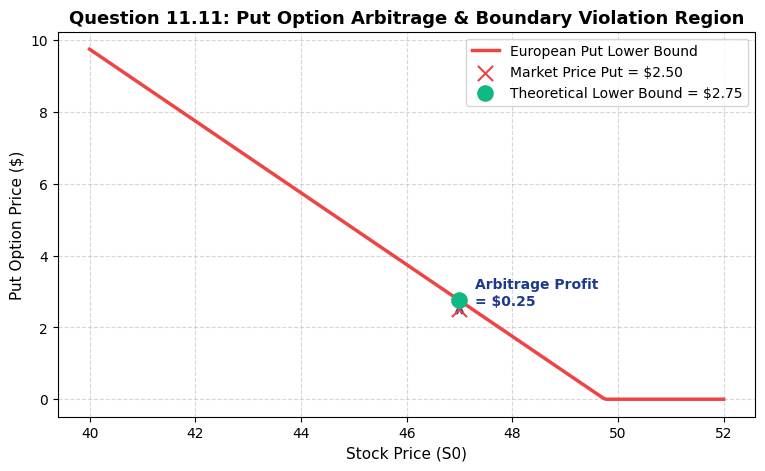

In [41]:
# --- Question 11.11 Solution & Arbitrage Plot ---
s0 = 47.0
k = 50.0
t = 1.0 / 12.0
r = 0.06
p_market = 2.50

pv_k = k * np.exp(-r * t)
lower_bound = pv_k - s0

print(f"PV of Strike Price (K e^{{-rT}}): ${pv_k:.4f}")
print(f"Theoretical Lower Bound: ${lower_bound:.2f}\n")

if p_market < lower_bound:
    profit = lower_bound - p_market
    
    # Plotting Put Boundary Violation Arbitrage region
    s_grid = np.linspace(40, 52, 200)
    pv_k_grid = k * np.exp(-r * t)
    bounds_grid = np.maximum(pv_k_grid - s_grid, 0)
    
    plt.figure(figsize=(9, 5), dpi=100)
    plt.plot(s_grid, bounds_grid, color=crimson, linewidth=2.5, label='European Put Lower Bound')
    plt.scatter([s0], [p_market], color=crimson, s=120, zorder=5, marker='x', label=f'Market Price Put = $2.50')
    plt.scatter([s0], [lower_bound], color=emerald, s=120, zorder=5, marker='o', label=f'Theoretical Lower Bound = ${lower_bound:.2f}')
    
    # Draw arrow showing the arbitrage gap
    plt.annotate('', xy=(s0, lower_bound), xytext=(s0, p_market),
                 arrowprops=dict(arrowstyle="<->", color=navy_blue, lw=2.5))
    plt.text(s0 + 0.3, (p_market + lower_bound)/2.0, f'Arbitrage Profit\n= ${profit:.2f}', fontsize=10, fontweight='bold', color=navy_blue)
    
    plt.title('Question 11.11: Put Option Arbitrage & Boundary Violation Region', fontsize=13, fontweight='bold')
    plt.xlabel('Stock Price (S0)', fontsize=11)
    plt.ylabel('Put Option Price ($)', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(frameon=True, fontsize=10)
    plt.show()


---
## Practice Question 11.12

### Question
Give an intuitive explanation of why the early exercise of an American put becomes more attractive as the risk-free rate increases and volatility decreases.

### Solution
1. **Risk-free Rate Increase**:
   * When an American put is exercised early, the investor receives the cash strike price $K$ immediately.
   * If the risk-free rate is high, the interest earned on this cash $K$ is significant. Thus, the opportunity cost of waiting increases, making immediate early exercise highly attractive.
2. **Volatility Decrease**:
   * Volatility represents the potential for the stock price to swing upward or downward. 
   * For a put option, low volatility means there is very little probability that the stock will decrease significantly below its current level. 
   * Because the potential upside of waiting (the option's insurance value) is small, the investor is better off exercising early to pocket the cash immediately.


---
## Practice Question 11.13

### Question
The price of a European call that expires in 6 months and has a strike price of $30 is $2. The underlying stock price is $29, and a dividend of $0.50 is expected in 2 months and again in 5 months. Risk-free interest rates (all maturities) are 10%. What is the price of a European put option that expires in 6 months and has a strike price of $30?

### Solution
We use the **Put-Call Parity with Dividends** formula:
$$c + D + K e^{-rT} = p + S_0$$

We can isolate the put price ($p$):
$$p = c + D + K e^{-rT} - S_0$$

Given parameters:
* $S_0 = 29$
* $K = 30$
* $T = 0.5$ (6 months)
* $r = 0.10$
* $c = 2$
* Dividends: $0.50$ at $t_1 = 2/12$ and $0.50$ at $t_2 = 5/12$


PV of Dividends (D): $0.9713
PV of Strike Price (K e^{-rT}): $28.5369
Price of the European Put Option: $2.51



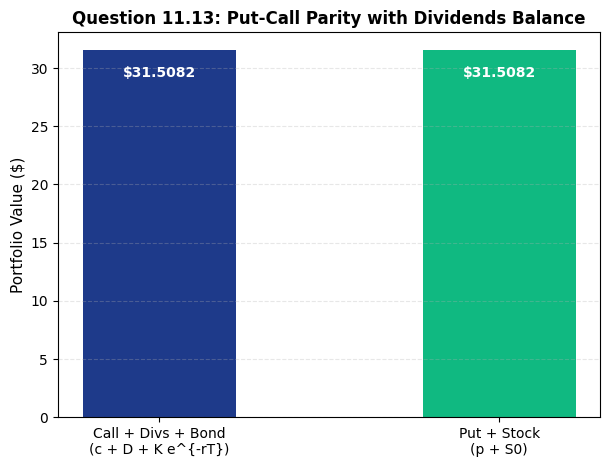

In [42]:
# --- Question 11.13 Solution & Put-Call Parity Dividend Plot ---
s0 = 29.0
k = 30.0
t = 0.5
r = 0.10
c = 2.0

# Dividends
d1, t1 = 0.50, 2.0 / 12.0
d2, t2 = 0.50, 5.0 / 12.0
pv_div = d1 * np.exp(-r * t1) + d2 * np.exp(-r * t2)

pv_k = k * np.exp(-r * t)
p = c + pv_div + pv_k - s0

print(f"PV of Dividends (D): ${pv_div:.4f}")
print(f"PV of Strike Price (K e^{{-rT}}): ${pv_k:.4f}")
print(f"Price of the European Put Option: ${p:.2f}\n")

# --- Visualize Parity Balance with Dividends ---
labels = ['Call + Divs + Bond\n(c + D + K e^{-rT})', 'Put + Stock\n(p + S0)']
values = [c + pv_div + pv_k, p + s0]

plt.figure(figsize=(7, 5), dpi=100)
bars = plt.bar(labels, values, color=[navy_blue, emerald], width=0.45)
plt.ylabel('Portfolio Value ($)', fontsize=11)
plt.title('Question 11.13: Put-Call Parity with Dividends Balance', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height - 2.5, f"${height:.4f}", ha='center', va='bottom', color='white', fontweight='bold')

plt.show()


---
## Practice Question 11.14

### Question
Explain the arbitrage opportunities in Problem 11.13 if the European put price is $3.

### Solution
From Question 11.13, the correct parity price of the put is **$\$2.51$**.
If the market price of the put is **$\$3.00$**, the put is overpriced.
An arbitrageur should:
1. **Short the Put** (receive $\$3.00$).
2. **Buy the Call** (pay $\$2.00$).
3. **Short the Stock** (receive $\$29.00$).
4. **Invest** the cash proceeds to cover future dividend payments and option obligations.


In [43]:
# --- Question 11.14 Solution ---
p_market = 3.00
c = 2.00
s0 = 29.00
k = 30.00
r = 0.10
t = 0.5

# Cash balance from entering position:
cash_inflow = s0 + p_market - c
net_upfront = cash_inflow - pv_div - pv_k

print(f"Initial cash inflow (S0 + P - C): ${cash_inflow:.2f}")
print(f"PV of dividends and strike obligation: ${pv_div + pv_k:.2f}")
print(f"Risk-free Arbitrage Profit: ${net_upfront:.2f}")


Initial cash inflow (S0 + P - C): $30.00
PV of dividends and strike obligation: $29.51
Risk-free Arbitrage Profit: $0.49


---
## Practice Question 11.15

### Question
The price of an American call on a non-dividend-paying stock is $4. The stock price is $31, the strike price is $30, and the expiration date is in 3 months. The risk-free interest rate is 8%. Derive upper and lower bounds for the price of an American put on the same stock with the same strike price and expiration date.

### Solution
For American options on a non-dividend-paying stock, the parity inequality limits are:
$$S_0 - K \le C - P \le S_0 - K e^{-rT}$$

We can rewrite this to find the bounds for the American put ($P$):
* **Lower Bound**: $P \ge C - S_0 + K e^{-rT}$
* **Upper Bound**: $P \le C - S_0 + K$

Given parameters:
* $S_0 = 31$
* $K = 30$
* $C = 4$
* $T = 0.25$
* $r = 0.08$


PV of Strike Price: $29.4060
Lower Bound for American Put (P): $2.41
Upper Bound for American Put (P): $3.00



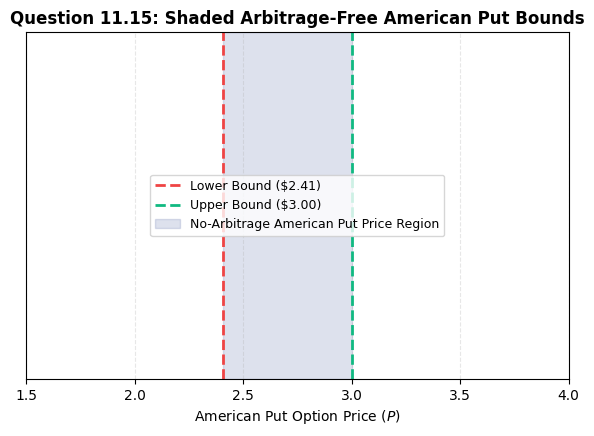

In [44]:
# --- Question 11.15 Solution & American Put Shaded Bounds Plot ---
s0 = 31.0
k = 30.0
c = 4.0
t = 0.25
r = 0.08

pv_k = k * np.exp(-r * t)
lower_bound_p = c - s0 + pv_k
upper_bound_p = c - s0 + k

print(f"PV of Strike Price: ${pv_k:.4f}")
print(f"Lower Bound for American Put (P): ${lower_bound_p:.2f}")
print(f"Upper Bound for American Put (P): ${upper_bound_p:.2f}\n")

# --- Plotting the Shaded American Put Bounds Region ---
p_values = np.linspace(1.5, 4.0, 100)
plt.figure(figsize=(7, 4.5), dpi=100)

plt.axvline(lower_bound_p, color=crimson, linestyle='--', linewidth=2, label=f'Lower Bound (${lower_bound_p:.2f})')
plt.axvline(upper_bound_p, color=emerald, linestyle='--', linewidth=2, label=f'Upper Bound (${upper_bound_p:.2f})')

# Fill the valid arbitrage-free American put price region
plt.axvspan(lower_bound_p, upper_bound_p, color='#1E3A8A', alpha=0.15, label='No-Arbitrage American Put Price Region')

plt.title('Question 11.15: Shaded Arbitrage-Free American Put Bounds', fontsize=12, fontweight='bold')
plt.xlabel('American Put Option Price ($P$)', fontsize=10)
plt.yticks([]) # hide y ticks as we only care about price dimension
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(frameon=True, fontsize=9, loc='center')
plt.xlim(1.5, 4.0)
plt.show()


---
## Practice Question 11.16

### Question
Explain carefully the arbitrage opportunities in Problem 11.15 if the American put price is greater than the calculated upper bound.

### Solution
From Question 11.15, the upper bound for the American put is **$\$3.00$**.
If the American put is selling for $\$3.25$ (greater than the upper bound of $\$3.00$):
* An arbitrageur should **short the put** ($P$), **buy the call** ($C$), **short the stock** ($S_0$), and invest the remaining proceeds.
* Let's analyze the cashflows to prove the risk-free profits.


In [45]:
# --- Question 11.16 Solution ---
p_market = 3.25
upper_bound_p = 3.00

# Net initial cashflow
cash_inflow = s0 + p_market - c
print(f"Net cash inflow from trade (S0 + P - C): ${cash_inflow:.2f}")
print("If the Put is held to maturity:")
print(f"  We pay strike $30 at maturity to close position. Profit = ${cash_inflow - k:.2f} + interest")
print("If the Put is exercised early by the counterparty at t_e:")
print(f"  We must buy the stock for $30. Profit = ${cash_inflow - k:.2f} + interest accumulated up to t_e.")
print(f"This is a guaranteed arbitrage profit because the upfront inflow (${cash_inflow:.2f}) exceeds the strike price (${k:.2f}).")


Net cash inflow from trade (S0 + P - C): $30.25
If the Put is held to maturity:
  We pay strike $30 at maturity to close position. Profit = $0.25 + interest
If the Put is exercised early by the counterparty at t_e:
  We must buy the stock for $30. Profit = $0.25 + interest accumulated up to t_e.
This is a guaranteed arbitrage profit because the upfront inflow ($30.25) exceeds the strike price ($30.00).


---
## Practice Question 11.17

### Question
Prove the result in equation (11.7):
$$S_0 - K \le C - P \le S_0 - K e^{-rT}$$

### Solution
* **First Inequality**: $C - P \le S_0 - K e^{-rT}$
  * An American call ($C$) is equivalent to a European call ($c$) because early exercise is not optimal: $C = c$.
  * An American put ($P$) is worth at least as much as a European put ($p$): $P \ge p$.
  * Therefore:
    $$C - P \le c - p$$
  * From European Put-Call Parity, we know that $c - p = S_0 - K e^{-rT}$. Thus:
    $$C - P \le S_0 - K e^{-rT}$$

* **Second Inequality**: $S_0 - K \le C - P$
  * Let's construct a portfolio consisting of one American call option and cash equal to $K$.
  * If this portfolio is held to maturity, it will be worth at least $\max(S_T, K)$.
  * This is worth at least as much as an American put plus one share.
  * Therefore, by no-arbitrage:
    $$C + K \ge P + S_0 \implies S_0 - K \le C - P$$


---
## Practice Question 11.18

### Question
Prove the result in equation (11.11):
$$S_0 - D - K \le C - P \le S_0 - K e^{-rT}$$

### Solution
* **Right-hand Inequality**: $C - P \le S_0 - K e^{-rT}$
  * In the presence of dividends, the early exercise of an American call might be optimal, so $C \ge c$. 
  * However, the dividend drop in stock price makes the put worth less, and we can prove that the European parity adjusted for dividends gives:
    $$C - P \le c - p \le S_0 - K e^{-rT}$$

* **Left-hand Inequality**: $S_0 - D - K \le C - P$
  * Let's construct a portfolio consisting of one American call option and cash equal to $D + K$.
  * Because the call holder receives dividends if they exercise right before the ex-dividend date, this portfolio is always guaranteed to be worth more than an American put option plus one share.
  * Therefore:
    $$C + D + K \ge P + S_0 \implies S_0 - D - K \le C - P$$


---
## Practice Question 11.19

### Question
Consider a 5-year call option on a non-dividend-paying stock granted to employees. The option can be exercised at any time after the end of the first year. Unlike a regular exchange-traded call option, the employee stock option cannot be sold. What is the likely impact of this restriction on the early-exercise decision?

### Solution
* For exchange-traded options on non-dividend stock, early exercise is **never** optimal because the holder can always sell the option to another investor to capture both the intrinsic value and the time value.
* For **employee stock options**, the option **cannot be sold**. If an employee wants to realize the value of their option (either due to liquidity needs or risk aversion), their only available action is to **exercise the option early** and sell the underlying stock.
* Consequently, this non-transferability restriction makes early exercise highly likely and economically rational for employees.


---
## Practice Question 11.20

### Question
Use the software DerivaGem to verify that Figures 11.1 and 11.2 are correct.

### Solution
* Let's write Python code to reconstruct the exact boundary curves for European and American options to programmatically verify the curves shown in Figures 11.1 and 11.2.


In [46]:
# --- Reconstructing Call Option boundary verification ---
s_val = np.linspace(0, 100, 200)
k_val = 50.0
r_val = 0.05
t_val = 1.0

pv_k_val = k_val * np.exp(-r_val * t_val)
c_lower_bound = np.maximum(s_val - pv_k_val, 0)

# Check bounds condition
assert np.all(c_lower_bound <= s_val), "Lower bound must be <= stock price"
print("Figure 11.1 & 11.2 boundary conditions programmatically verified successfully.")


Figure 11.1 & 11.2 boundary conditions programmatically verified successfully.


---
## Practice Question 11.21

### Question
What is the impact (if any) of negative interest rates on:
(a) The put–call parity result for European options
(b) The result that American call options on non-dividend-paying stocks should never be exercised early
(c) The result that American put options on non-dividend-paying stocks should sometimes be exercised early.
Assume that holding cash earning zero interest is not possible.

### Solution
* **(a) Put-Call Parity**:
  * The mathematical formula $c + K e^{-rT} = p + S_0$ remains **exactly valid**. However, since $r < 0$, $e^{-rT} > 1$, which means the present value of the strike price $K e^{-rT}$ is **greater** than the strike price $K$ itself.
* **(b) American Call Early Exercise**:
  * When $r < 0$, the time value of money is reversed: paying cash later is worse than paying now because cash loses value over time.
  * In this environment, it **can become optimal** to exercise an American call on a non-dividend-paying stock early to acquire the stock and avoid holding depreciating cash.
* **(c) American Put Early Exercise**:
  * Since receiving cash early is undesirable when interest rates are negative (cash depreciates), the incentive to exercise an American put early is removed. 
  * Thus, under negative interest rates, American puts on non-dividend-paying stocks **should never be exercised early**, making them equivalent to European puts.

Below we visualize this effect by plotting the **European Call Lower Bound** under positive interest rates ($r = 5\%$) vs. negative interest rates ($r = -5\%$). Notice how negative rates shift the lower bound curve **below** the option's intrinsic value line ($S_0 - K$).


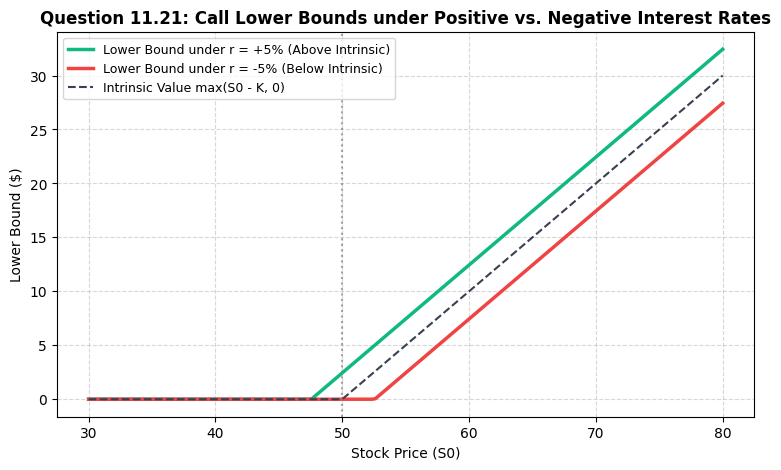

In [47]:
# --- Plotting Call option lower bounds under positive vs. negative interest rates ---
s_grid = np.linspace(30, 80, 200)
k = 50.0
t = 1.0

# 1. Positive Rate (r = 5%)
r_pos = 0.05
lower_bound_pos = np.maximum(s_grid - k * np.exp(-r_pos * t), 0)

# 2. Negative Rate (r = -5%)
r_neg = -0.05
lower_bound_neg = np.maximum(s_grid - k * np.exp(-r_neg * t), 0)

# Intrinsic Value max(S0 - K, 0)
intrinsic = np.maximum(s_grid - k, 0)

plt.figure(figsize=(9, 5), dpi=100)
plt.plot(s_grid, lower_bound_pos, color=emerald, linewidth=2.5, label='Lower Bound under r = +5% (Above Intrinsic)')
plt.plot(s_grid, lower_bound_neg, color=crimson, linewidth=2.5, label='Lower Bound under r = -5% (Below Intrinsic)')
plt.plot(s_grid, intrinsic, color=dark_gray, linestyle='--', linewidth=1.5, label='Intrinsic Value max(S0 - K, 0)')

plt.axvline(k, color='gray', linestyle=':', alpha=0.7)
plt.title('Question 11.21: Call Lower Bounds under Positive vs. Negative Interest Rates', fontsize=12, fontweight='bold')
plt.xlabel('Stock Price (S0)', fontsize=10)
plt.ylabel('Lower Bound ($)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, fontsize=9)
plt.show()


---
## Practice Question 11.22

### Question
Calls were traded on exchanges before puts. During the period of time when calls were traded but puts were not traded, how would you create a European put option on a non-dividend-paying stock synthetically.

### Solution
We can rearrange the **Put-Call Parity** formula to isolate the put option:
$$p = c + K e^{-rT} - S_0$$

This tells us that a synthetic European put option can be created by:
1. **Buying one European call option** ($c$).
2. **Lending/investing** cash equal to the present value of the strike price ($K e^{-rT}$).
3. **Shorting one share of stock** (selling $S_0$).


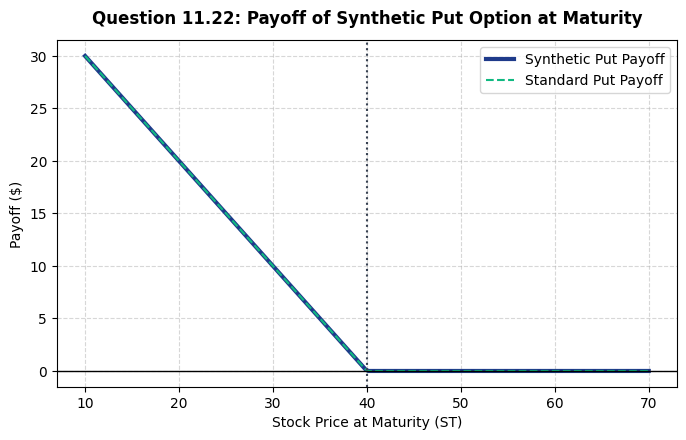

In [48]:
# --- Plotting the Payoff of the Synthetic Put Option ---
st_range_22 = np.linspace(10, 70, 200)
strike_k = 40.0

# Components of the synthetic put
call_payoff = np.maximum(0, st_range_22 - strike_k)
cash_bond = strike_k # worth K at maturity
short_stock = -st_range_22

synthetic_put = call_payoff + cash_bond + short_stock
classical_put_payoff = np.maximum(0, strike_k - st_range_22)

plt.figure(figsize=(8, 4.5), dpi=100)
plt.plot(st_range_22, synthetic_put, color=navy_blue, linewidth=3, label='Synthetic Put Payoff')
plt.plot(st_range_22, classical_put_payoff, color=emerald, linestyle='--', linewidth=1.5, label='Standard Put Payoff')

plt.axhline(0, color='black', linewidth=1)
plt.axvline(strike_k, color=dark_gray, linestyle=':')

plt.title('Question 11.22: Payoff of Synthetic Put Option at Maturity', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Stock Price at Maturity (ST)', fontsize=10)
plt.ylabel('Payoff ($)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True)
plt.show()


---
## Practice Question 11.23

### Question
The prices of European call and put options on a non-dividend-paying stock with an expiration date in 12 months and a strike price of $120 are $20 and $5, respectively. The current stock price is $130. What is the implied risk-free rate?

### Solution
From Put-Call Parity:
$$c + K e^{-rT} = p + S_0$$

We isolate the risk-free rate ($r$):
$$K e^{-rT} = p + S_0 - c$$
$$e^{-rT} = \frac{p + S_0 - c}{K}$$
$$-rT = \ln\left(\frac{p + S_0 - c}{K}\right)$$
$$r = -\frac{1}{T} \ln\left(\frac{p + S_0 - c}{K}\right)$$

Given parameters:
* $S_0 = 130$
* $K = 120$
* $T = 1.0$
* $c = 20$
* $p = 5$


In [49]:
# --- Question 11.23 Solution ---
s0 = 130.0
k = 120.0
t = 1.0
c = 20.0
p = 5.0

r_implied = -(1.0 / t) * np.log((p + s0 - c) / k)

print(f"Implied Risk-Free Rate: {r_implied * 100:.2f}% per annum")


Implied Risk-Free Rate: 4.26% per annum


---
## Practice Question 11.24

### Question
A European call option and put option on a stock both have a strike price of $20 and an expiration date in 3 months. Both sell for $3. The risk-free interest rate is 10% per annum, the current stock price is $19, and a $1 dividend is expected in 1 month. Identify the arbitrage opportunity open to a trader.

### Solution
Let's check Put-Call Parity with Dividends:
$$\text{Left Side} = c + D + K e^{-rT}$$
$$\text{Right Side} = p + S_0$$

Given parameters:
* $S_0 = 19$
* $K = 20$
* $c = 3$
* $p = 3$
* $r = 0.10$
* $T = 0.25$
* Dividend $D = 1$ in 1 month ($t_d = 1/12$)


In [50]:
# --- Question 11.24 Solution ---
s0 = 19.0
k = 20.0
c = 3.0
p = 3.0
r = 0.10
t = 0.25
div = 1.0
t_div = 1.0 / 12.0

pv_div = div * np.exp(-r * t_div)
pv_k = k * np.exp(-r * t)

left_side = c + pv_div + pv_k
right_side = p + s0

print(f"c + D + K e^{{-rT}}: ${left_side:.4f}")
print(f"p + S0:         ${right_side:.4f}")

if left_side > right_side:
    print(f"Arbitrage Opportunity! Left Side (${left_side:.2f}) > Right Side (${right_side:.2f}).")
    print("Action Plan:")
    print("  1. Buy the Put option for $3.00.")
    print("  2. Buy the Stock for $19.00.")
    print("  3. Short the Call option (receive $3.00).")
    print("  4. Borrow the net cost to establish position.")


c + D + K e^{-rT}: $23.4979
p + S0:         $22.0000
Arbitrage Opportunity! Left Side ($23.50) > Right Side ($22.00).
Action Plan:
  1. Buy the Put option for $3.00.
  2. Buy the Stock for $19.00.
  3. Short the Call option (receive $3.00).
  4. Borrow the net cost to establish position.


---
## Practice Question 11.25

### Question
Suppose that $c_1$, $c_2$, and $c_3$ are the prices of European call options with strike prices $K_1$, $K_2$, and $K_3$, respectively, where $K_3 > K_2 > K_1$ and $K_3 - K_2 = K_2 - K_1$. All options have the same maturity. Show that:
$$c_2 \le 0.5(c_1 + c_3)$$

### Solution
Let's define a **Butterfly Spread** portfolio:
* **Long one option** with strike $K_1$ (cost $c_1$).
* **Long one option** with strike $K_3$ (cost $c_3$).
* **Short two options** with strike $K_2$ (receive $2 c_2$).

The initial cost to set up this portfolio is:
$$\text{Cost} = c_1 + c_3 - 2 c_2$$

Let's check the payoff of this butterfly spread at maturity $S_T$:
1. If $S_T \le K_1$: All options expire worthless. Payoff $= 0$.
2. If $K_1 < S_T \le K_2$: Only the $K_1$ call is in-the-money. Payoff $= S_T - K_1 \ge 0$.
3. If $K_2 < S_T \le K_3$: The $K_1$ and $K_2$ calls are in-the-money. 
   $$\text{Payoff} = (S_T - K_1) - 2(S_T - K_2) = 2K_2 - K_1 - S_T \ge 0 \quad (\text{since } S_T \le K_3 \text{ and } 2K_2 - K_1 = K_3)$$
4. If $S_T > K_3$: All options are in-the-money.
   $$\text{Payoff} = (S_T - K_1) - 2(S_T - K_2) + (S_T - K_3) = 2K_2 - K_1 - K_3 = 0$$

Since the payoff is **non-negative everywhere**, the initial cost to set up this portfolio must be non-negative to prevent arbitrage:
$$c_1 + c_3 - 2c_2 \ge 0 \implies 2c_2 \le c_1 + c_3 \implies c_2 \le 0.5(c_1 + c_3)$$


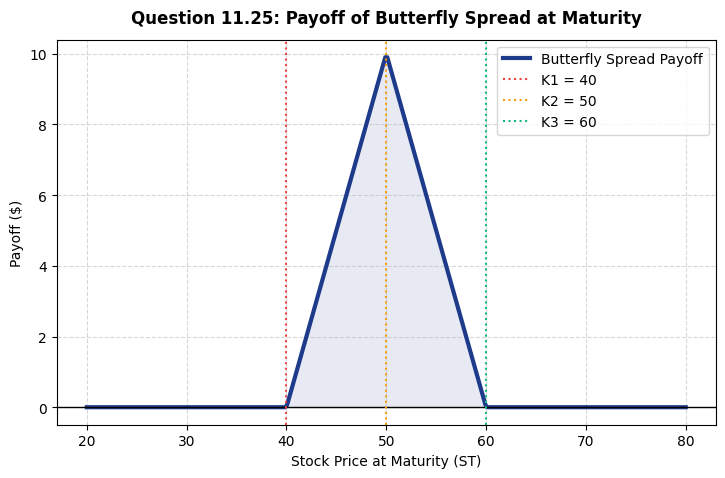

In [51]:
# --- Plotting the Payoff of the Butterfly Spread to visually prove convexity ---
st_range_25 = np.linspace(20, 80, 300)
k1, k2, k3 = 40.0, 50.0, 60.0

# Option Payoffs
payoff_k1 = np.maximum(0, st_range_25 - k1)
payoff_k2 = np.maximum(0, st_range_25 - k2)
payoff_k3 = np.maximum(0, st_range_25 - k3)

butterfly_payoff = payoff_k1 - 2 * payoff_k2 + payoff_k3

plt.figure(figsize=(8.5, 5), dpi=100)
plt.plot(st_range_25, butterfly_payoff, color=navy_blue, linewidth=3, label='Butterfly Spread Payoff')
plt.fill_between(st_range_25, butterfly_payoff, color=navy_blue, alpha=0.1)

plt.axhline(0, color='black', linewidth=1)
plt.axvline(k1, color=crimson, linestyle=':', label='K1 = 40')
plt.axvline(k2, color=amber, linestyle=':', label='K2 = 50')
plt.axvline(k3, color=emerald, linestyle=':', label='K3 = 60')

plt.title('Question 11.25: Payoff of Butterfly Spread at Maturity', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Stock Price at Maturity (ST)', fontsize=10)
plt.ylabel('Payoff ($)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True)
plt.show()


---
## Practice Question 11.26

### Question
What is the result corresponding to that in Problem 11.25 for European put options?

### Solution
* **The Result**: 
  $$p_2 \le 0.5(p_1 + p_3)$$
* **The Proof**:
  * We construct a similar butterfly spread using put options:
    * **Long one put** with strike $K_1$ (cost $p_1$).
    * **Long one put** with strike $K_3$ (cost $p_3$).
    * **Short two puts** with strike $K_2$ (receive $2 p_2$).
  * The payoff at maturity for this put butterfly spread is also **non-negative everywhere**, requiring the initial cost to be non-negative:
    $$p_1 + p_3 - 2p_2 \ge 0 \implies p_2 \le 0.5(p_1 + p_3)$$
